In [2]:
!pip install torchmetrics pandas datasets numpy torchmetrics scikit-learn seaborn torchcodec torchaudio librosa ipywidgets torchvision wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.9/22.9 MB 136.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [wandb]32m2/3 [wandb]uf]


In [1]:
# -----------------------------
# 1. Imports
# -----------------------------
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from datasets import load_from_disk, load_dataset, concatenate_datasets, DatasetDict
import torchmetrics
from tqdm import tqdm
import numpy as np
import random
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os # Added for path joining
from IPython.lib.display import Audio as AudioDisplay
import wandb

/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# -----------------------------
# 2. Configuration & Setup
# -----------------------------
SEED = 42
BATCH_SIZE = 128
NUM_WORKERS = 24
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 4e-4
MODEL_SAVE_PATH = "./resnet_custom.pt"
EPOCHS=15

# --- Set Seeds for Reproducibility ---
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Disabling benchmark mode can help reproducibility
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

print(f"Using device: {DEVICE}")
print(f"Number of workers: {NUM_WORKERS}")

Using device: cuda
Number of workers: 24


In [4]:
wandb.login("11cb73104f2523bd2e88aae950c751bfb0a41a8b")
import wandb
run = wandb.init(
    entity="hibou",
    project="acoustic",
    config={
        "model": "Resnet_Custom",
        "dataset": "ds_1_melspecto_aug07_balanced_chunked",
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "epochs": EPOCHS,
        "seed": SEED,
        "augmentation": True
    },
    name=f"resnet_custom-ds1-aug_3-{EPOCHS}epochs"
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/pierre/.netrc
wandb: Currently logged in as: cqsv20ajs (hibou) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
# dataset = load_dataset("Hibou-Foundation/ds_121_melspecto_noaug_balanced_chunked")
dataset = load_from_disk("../../dataset/ds_1_melspecto_aug_0-7_balanced_chunked.hf")
dataset = dataset.with_format("torch", columns=["audio", "label"])

print("\nDataset splits:")
print({k: v.shape for k, v in dataset.items()})

print("\nDataset features:")
print(dataset["train"].features)


Dataset splits:
{'train': (563926, 2), 'val': (42198, 2), 'test': (44844, 2)}

Dataset features:
{'audio': List(List(List(Value('float64')))), 'label': ClassLabel(names=['other', 'drone'])}


In [4]:
from functools import partial


def collate_fn(batch, augment=False, snr_range=(5, 20)):
    """
    Prepares a batch for the model.
    If 'augment' is True, applies SpecAugment.
    """
    xs = []
    for audio in batch:
        spec = audio["audio"]

        # if augment:
        #     # Mask time dimension (width)
        #     t = random.randrange(0, 20) # Max mask width 20 frames
        #     t0 = random.randrange(0, spec.shape[1] - t)
        #     spec[:, t0:t0+t] = 0
        #
        #     # Mask freq dimension (height)
        #     f = random.randrange(0, 10) # Max mask width 10 bins
        #     f0 = random.randrange(0, spec.shape[0] - f)
        #     spec[f0:f0+f, :] = 0
        #
        #     # 2. Multiplicative Noise (Gain variation)
        #     # Simulates volume changes without breaking Log math
        #     gain = random.uniform(0.8, 1.2)
        #     spec = spec * gain

        xs.append(spec)

    ys = [b["label"] for b in batch]

    # Stack spectrograms into a batch
    # (B, H, W) -> (B, 1, H, W)
    xs = torch.stack(xs, dim=0)

    # Convert labels to float and add a dimension for BCEWithLogitsLoss
    # (B,) -> (B, 1)
    ys = torch.tensor(ys, dtype=torch.float32).unsqueeze(1)

    return xs, ys


collate_aug = partial(collate_fn, augment=True, snr_range=(5, 20))
collate_noaug = partial(collate_fn, augment=False)
# Create DataLoaders
train_loader = DataLoader(dataset["train"], batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_aug, pin_memory=True)
valid_loader = DataLoader(dataset["val"], batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_noaug, pin_memory=True)
test_loader = DataLoader(dataset["test"], batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, collate_fn=collate_noaug, pin_memory=True)

print(f"\nCreated DataLoaders with Batch Size: {BATCH_SIZE}")

# Check a sample batch
try:
    sample_x, sample_y = next(iter(train_loader))
    print(f"Sample batch shape - X: {sample_x.shape}, Y: {sample_y.shape}")
except Exception as e:
    print(f"Could not load a sample batch: {e}")


Created DataLoaders with Batch Size: 128
Sample batch shape - X: torch.Size([128, 1, 128, 32]), Y: torch.Size([128, 1])


In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.prelu = nn.PReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection to match dimensions
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.prelu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x) # The "residual" connection
        out = self.prelu(out)
        return out

class AudioResNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Initial convolution (larger kernel can be good for spectrograms)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=(2, 1), padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.prelu = nn.PReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = ResidualBlock(32, 64, stride=2)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)

        self.pool2 = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.PReLU(),
            nn.Dropout(0.5), # Increase dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.pool1(self.prelu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = AudioResNet().to(DEVICE)

In [6]:
# -----------------------------
# 7. Loss, Optimizer, & Metric
# -----------------------------
criterion = nn.BCEWithLogitsLoss() # Handles sigmoid internally, more stable
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Use torchmetrics for accuracy (stateful)
metric_acc = torchmetrics.classification.BinaryAccuracy().to(DEVICE)

In [9]:
best_val_acc = 0.0
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("\nStarting training...")

for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    running_train_loss = 0.0
    metric_acc.reset()

    # Use tqdm for progress bar
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")

    for x, y in train_pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

        # Forward pass
        out = model(x)
        loss = criterion(out, y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update metrics
        running_train_loss += loss.item() * x.size(0)
        metric_acc.update(out, y) # Update stateful metric

        train_pbar.set_postfix(loss=loss.item())

    # Step the scheduler
    scheduler.step()

    # Calculate epoch metrics
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = metric_acc.compute().item()

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)

    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    metric_acc.reset()

    valid_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]", unit="batch")

    with torch.no_grad():
        for x, y in valid_pbar:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            out = model(x)
            loss = criterion(out, y)

            running_val_loss += loss.item() * x.size(0)
            metric_acc.update(out, y)

            valid_pbar.set_postfix(loss=loss.item())

    epoch_val_loss = running_val_loss / len(valid_loader.dataset)
    epoch_val_acc = metric_acc.compute().item()

    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    # Print epoch results
    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f}")

    # Save the best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved new best model to {MODEL_SAVE_PATH} (Val Acc: {best_val_acc:.4f})")

print("\nTraining complete.")


Starting training...


Epoch 1/15 [Valid]: 100%|██████████| 330/330 [00:05<00:00, 64.08batch/s, loss=0.0519]  



Epoch 1/15 | Train Loss: 0.0613 | Train Acc: 0.9784 | Val Loss: 0.0306 | Val Acc: 0.9895
Saved new best model to ./resnet_custom.pt (Val Acc: 0.9895)


Epoch 2/15 [Valid]: 100%|██████████| 330/330 [00:04<00:00, 68.80batch/s, loss=0.00452] 



Epoch 2/15 | Train Loss: 0.0243 | Train Acc: 0.9920 | Val Loss: 0.0266 | Val Acc: 0.9913
Saved new best model to ./resnet_custom.pt (Val Acc: 0.9913)


...


Epoch 13/15 | Train Loss: 0.0001 | Train Acc: 1.0000 | Val Loss: 0.0318 | Val Acc: 0.9964
Saved new best model to ./resnet_custom.pt (Val Acc: 0.9964)


Epoch 14/15 [Valid]: 100%|██████████| 330/330 [00:05<00:00, 65.48batch/s, loss=0.000294] 



Epoch 14/15 | Train Loss: 0.0001 | Train Acc: 1.0000 | Val Loss: 0.0318 | Val Acc: 0.9963


Epoch 15/15 [Valid]: 100%|██████████| 330/330 [00:05<00:00, 65.15batch/s, loss=6.06e-5]  



Epoch 15/15 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0317 | Val Acc: 0.9965
Saved new best model to ./resnet_custom.pt (Val Acc: 0.9965)

Training complete.


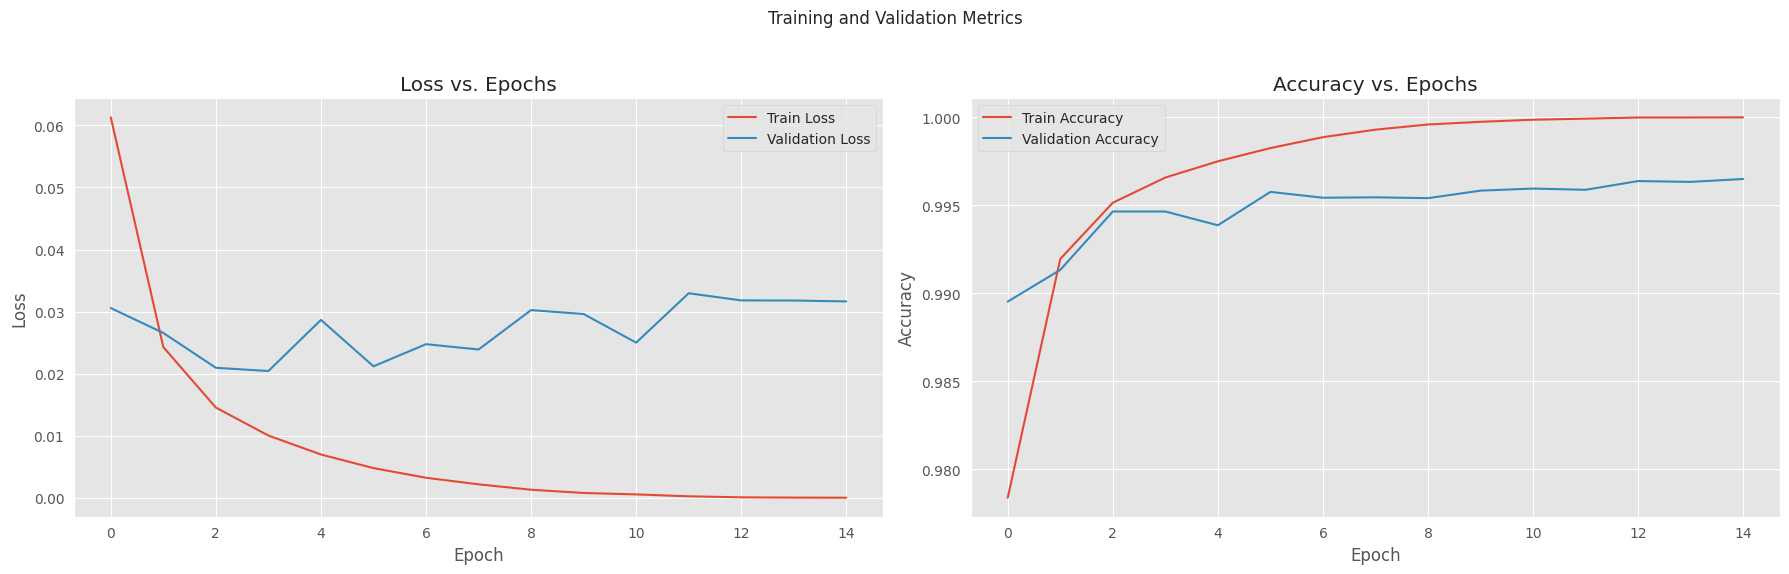

In [10]:
# -----------------------------
# 9. Plot Training History
# -----------------------------
if history["train_loss"]: # Check if training actually ran
    plt.style.use("ggplot")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot Loss
    ax1.plot(history["train_loss"], label="Train Loss")
    ax1.plot(history["val_loss"], label="Validation Loss")
    ax1.set_title("Loss vs. Epochs")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    # Plot Accuracy
    ax2.plot(history["train_acc"], label="Train Accuracy")
    ax2.plot(history["val_acc"], label="Validation Accuracy")
    ax2.set_title("Accuracy vs. Epochs")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.suptitle("Training and Validation Metrics")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [7]:
print(f"Loading best model from {MODEL_SAVE_PATH}...")
model = model.to(DEVICE)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()
print("Loaded best model and set to eval mode.")

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        probs = torch.sigmoid(logits)  # Convert logits to probabilities
        preds = (probs > 0.5).float()  # Apply 0.5 threshold for predictions

        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(y.cpu().numpy().flatten())

print("\nTest evaluation complete.")

Loading best model from ./resnet_custom.pt...
Loaded best model and set to eval mode.


Testing: 100%|██████████| 351/351 [00:05<00:00, 62.36it/s]


Test evaluation complete.



Test Accuracy: 99.33%

Classification Report:
              precision    recall  f1-score   support

       other      0.990     0.996     0.993     22422
       drone      0.996     0.990     0.993     22422

    accuracy                          0.993     44844
   macro avg      0.993     0.993     0.993     44844
weighted avg      0.993     0.993     0.993     44844



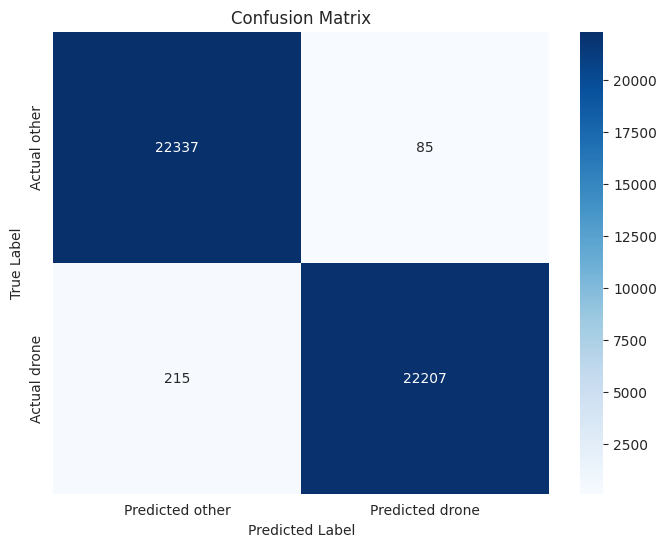


Results DataFrame head:
   true_label  pred_label    confidence
0         0.0         0.0  5.281485e-15
1         0.0         0.0  8.951064e-15
2         0.0         0.0  8.786528e-19
3         0.0         0.0  6.404446e-08
4         1.0         1.0  1.000000e+00


In [8]:
# -----------------------------
# 11. Analyze Test Results
# -----------------------------
# --- Overall Accuracy ---
accuracy = accuracy_score(all_labels, all_preds)
# run.log({"test/accuracy": accuracy})
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# --- Classification Report ---
# Assuming 0 is 'fake' and 1 is 'real', or 'Class 0' and 'Class 1'
# Adjust target_names if you have the actual class names
try:
    # Try to get names from dataset features if they exist
    target_names = dataset["train"].features["label"].names
    if len(target_names) != 2: # Fallback if it's not binary
        target_names = ["Class 0", "Class 1"]
except:
    target_names = ["Class 0", "Class 1"]

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))

# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Predicted {target_names[0]}", f"Predicted {target_names[1]}"],
            yticklabels=[f"Actual {target_names[0]}", f"Actual {target_names[1]}"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
# run.log({
#     "test/confusion_matrix": wandb.plot.confusion_matrix(
#         y_true=all_labels,
#         preds=all_preds,
#         class_names=target_names,
#         title="Confusion Matrix Dataset Test"
#     )
# })

# --- Store results in a DataFrame (optional) ---
df_results = pd.DataFrame({
    "true_label": all_labels,
    "pred_label": all_preds,
    "confidence": all_probs
})

print("\nResults DataFrame head:")
print(df_results.head())

In [9]:
ds_all_tests = load_dataset("Hibou-Foundation/drone_all_test_datasets")
ds_test_1 = ds_all_tests["drone_test"]
ds_test_2 = ds_all_tests["drone_test_2"]
ds_parabole_1 = ds_all_tests["mic_parabole"]
ds_parabole_2 = ds_all_tests["parabole2"]

In [10]:
import librosa
def convert_to_mel_spectrogram(data):
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
     # Convert to log scale (dB)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def collate_fn_librosa_test(batch):
    inputs = []
    labels = []

    for item in batch:
        waveforme = item["audio"]["array"]
        wave = convert_to_mel_spectrogram(waveforme)
        # wave = wave.repeat(3, 1, 1)
        inputs.append(wave)
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    # (ResNet requires fixed size)
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )  # → [B, 3, 128, T_max]

    labels = torch.tensor(labels, dtype=torch.float32)

    return inputs, labels

In [16]:
test_loader_1 = DataLoader(
    ds_test_1,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1,
    collate_fn=collate_fn_librosa_test,
)
test_loader_2 = DataLoader(
    ds_test_2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1,
    collate_fn=collate_fn_librosa_test,
)
test_loader_3 = DataLoader(
    ds_parabole_1,
    batch_size=1,
    shuffle=False,
    num_workers=1,
    collate_fn=collate_fn_librosa_test,
)
test_loader_4 = DataLoader(
    ds_parabole_2,
    batch_size=1,
    shuffle=False,
    num_workers=1,
    collate_fn=collate_fn_librosa_test,
)

In [17]:
y_true1, y_pred1, y_true2, y_pred2, y_pred3, y_true3, y_pred4, y_true4 = [], [], [], [], [], [], [], []

with torch.no_grad():
    for x, y in tqdm(test_loader_1, desc="Testing"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_pred1.extend(preds.cpu().numpy())
        y_true1.extend(y.cpu().numpy())

with torch.no_grad():
    for x, y in tqdm(test_loader_2, desc="Testing"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_pred2.extend(preds.cpu().numpy())
        y_true2.extend(y.cpu().numpy())

with torch.no_grad():
    for x, y in tqdm(test_loader_3, desc="Testing"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_pred3.extend(preds.cpu().numpy())
        y_true3.extend(y.cpu().numpy())

with torch.no_grad():
    for x, y in tqdm(test_loader_4, desc="Testing"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_pred4.extend(preds.cpu().numpy())
        y_true4.extend(y.cpu().numpy())

Testing: 100%|██████████| 85/85 [00:01<00:00, 54.47it/s]


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except:
        auc = float("nan")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
    }

metrics1 = compute_metrics(y_true1, y_pred1)
metrics2 = compute_metrics(y_true2, y_pred2)
metrics3 = compute_metrics(y_true3, y_pred3)
metrics4 = compute_metrics(y_true4, y_pred4)
print(metrics1)
print(metrics2)
print(metrics3)
print(metrics4)

{'accuracy': 0.6461366181410975, 'precision': 1.0, 'recall': 0.17708333333333334, 'f1': 0.3008849557522124, 'auc': 0.5885416666666666, 'confusion_matrix': array([[509,   0],
       [316,  68]])}
{'accuracy': 0.906951871657754, 'precision': 1.0, 'recall': 0.9069186875891584, 'f1': 0.9511875818215823, 'auc': 0.9534593437945792, 'confusion_matrix': array([[   1,    0],
       [ 261, 2543]])}
{'accuracy': 0.8373983739837398, 'precision': 1.0, 'recall': 0.7435897435897436, 'f1': 0.8529411764705882, 'auc': 0.8717948717948718, 'confusion_matrix': array([[45,  0],
       [20, 58]])}
{'accuracy': 0.8470588235294118, 'precision': 1.0, 'recall': 0.7796610169491526, 'f1': 0.8761904761904762, 'auc': 0.8898305084745763, 'confusion_matrix': array([[26,  0],
       [13, 46]])}


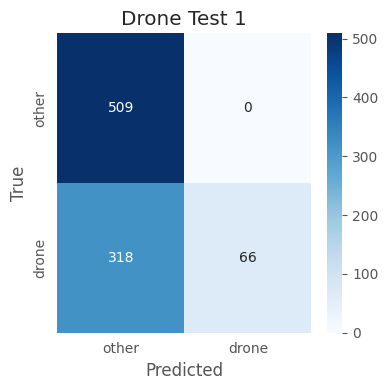

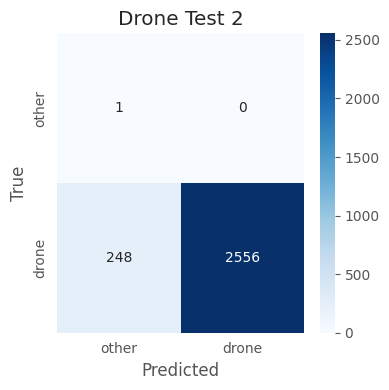

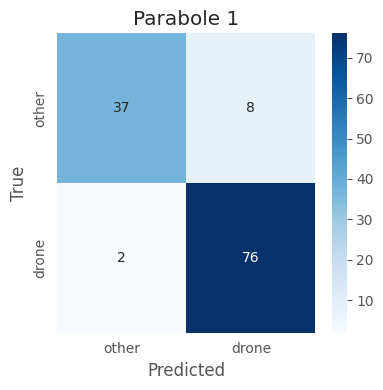

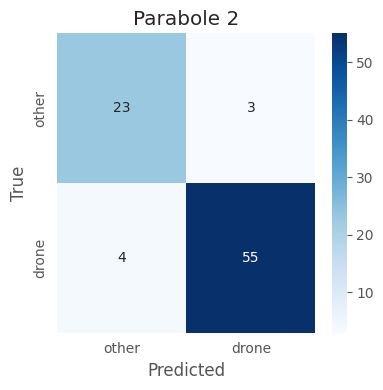

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = ["other", "drone"]

def plot_confusion(cm, title):
    plt.figure(figsize=(4,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(metrics1["confusion_matrix"], "Drone Test 1")
plot_confusion(metrics2["confusion_matrix"], "Drone Test 2")
plot_confusion(metrics3["confusion_matrix"], "Parabole 1")
plot_confusion(metrics4["confusion_matrix"], "Parabole 2")

In [13]:
def infer_from_folder(folder_path: str):
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    results = []

    for file in files:
        file_path = os.path.join(folder_path, file)
        waveform, sr = librosa.load(file_path, sr=16000)
        mel_spec = convert_to_mel_spectrogram(waveform).unsqueeze(0)
        # mel_spec = mel_spec.repeat(3, 1, 1).unsqueeze(0)  # [1, 3, 128, T]
        mel_spec = mel_spec.to(DEVICE)

        with torch.no_grad():
            logits = model(mel_spec)
            probs = torch.sigmoid(logits).squeeze(1)
            pred = (probs > 0.5).float().cpu().item()
            confidence = probs.cpu().item()

        print(file, int(pred))
        results.append({
            "file": file,
            "predicted_label": int(pred),
            "confidence": confidence
        })

    from pprint import pprint
    # pprint(results)

print(f"0 is {dataset['train'].features['label'].names[0]}, 1 is {dataset['train'].features['label'].names[1]}")
infer_from_folder("/home/pierre/Documents/Projects/PST4/AI/data/test/parabole3/drone")

0 is other, 1 is drone
rec_chunk19.wav 0
rec_chunk20.wav 0
rec_chunk21.wav 0
rec_chunk22.wav 0
rec_chunk23.wav 0
rec_chunk24.wav 0
rec_chunk25.wav 0
rec_chunk26.wav 0
rec_chunk27.wav 0
rec_chunk28.wav 0
rec_chunk29.wav 0
rec_chunk30.wav 0
rec_chunk31.wav 0
rec_chunk32.wav 1
rec_chunk33.wav 0
rec_chunk34.wav 1
rec_chunk35.wav 0
rec_chunk36.wav 0
rec_chunk37.wav 0
rec_chunk38.wav 1
rec_chunk39.wav 1
rec_chunk40.wav 1
rec_chunk41.wav 1
rec_chunk42.wav 0
rec_chunk43.wav 0
rec_chunk44.wav 0
rec_chunk45.wav 1
rec_chunk46.wav 0
rec_chunk47.wav 0
rec_chunk48.wav 0
rec_chunk49.wav 0
rec_chunk50.wav 1
rec_chunk51.wav 0
rec_chunk52.wav 0
rec_chunk53.wav 0
rec_chunk54.wav 0


In [32]:
wandb.finish()

test/accuracy,▁
test/accuracy,0.99373
